# Chapter 03: Basic Concepts and Models

Source span: printed pages 25-56; PDF pages 43-73. The source is used for chapter orientation, terminology, and coverage only. The prose, examples, diagrams, computations, and artifacts below are original course material.

## Chapter Question

How do probability models on a circle differ from probability models on a line once the zero direction is only a coordinate choice? This chapter answers that by treating a circular distribution as three linked objects: arc probabilities, a sequence of trigonometric moments, and a density that can be built from model families such as uniform, von Mises, cardioid, wrapped, and projected distributions.

The guiding idea is that no calculation should depend on where the angle axis was cut. A probability assigned to an arc may cross zero degrees; a characteristic function is indexed by integers because only integer harmonics survive wrapping; and convolution is naturally addition modulo `2*pi`. The visuals below make those facts inspectable rather than leaving them as formulas.


## Translation Guide

| Book concept | Computational object in this notebook | Inspection target |
| --- | --- | --- |
| Circular distribution function | A right-continuous unwrapped function `F(x)` satisfying `F(x + 2*pi) = F(x) + 1` | Arc probabilities are differences of the periodic extension, even when the arc crosses the cut point. |
| Characteristic function | Integer-indexed moments `phi_p = E[exp(i p theta)]` | The real and imaginary parts are the cosine and sine trigonometric moments. |
| Fourier reconstruction | Partial sums built from the moments | More harmonics recover sharper circular density features without introducing a preferred origin. |
| Uniform, von Mises, cardioid, wrapped, projected models | Chapter-local density and sampling functions | Each family has a visible generative story and a normalization check. |
| Circular convolution | Addition modulo `2*pi`, checked with FFT quadrature and moment products | Wrapped-normal convolution multiplies characteristic functions and stays wrapped normal. |

Library routing: Matplotlib is used for durable 2D chapter diagrams, Plotly for a hoverable model/Fourier explorer, SciPy for Bessel functions, optimization, and cumulative quadrature, and NumPy for direct circular-grid integration. These choices match a one-dimensional curved sample space; mesh, GIS, CV, and 3D surface tools would add machinery without clarifying the chapter geometry.


## Standalone Reading Guide

This chapter is the distribution-theory bridge between circular data displays and circular inference. On the line, a distribution function can be read by moving from left to right. On the circle there is no privileged left endpoint, so the notebook treats probabilities as arc masses and treats integer Fourier coefficients as the natural analogue of a characteristic function. The central habit is to check every model in three ways: as a density around the circle, as a small list of trigonometric moments, and as a generator that explains how such angles could arise.

The visual sequence follows that habit. The arc-probability panel shows how a probability statement can cross the cut point without becoming discontinuous as a circular event. The Fourier reconstruction panel makes the first few harmonics inspectable: a first harmonic gives a preferred direction, a second harmonic reveals axial structure, and missing harmonics are a useful diagnostic for symmetry. The model gallery then compares von Mises, cardioid, wrapped, and projected families by the features they can and cannot express. The wrapping-versus-projection figure is included because two models can have similar marginal density curves while coming from very different mechanisms.

When editing or extending the notebook, use the checks as a contract. A circular density should integrate to one on a full period, moments should agree with the corresponding Fourier coefficients, and the uniform model should kill nonzero harmonics. Those small executable tests keep the pictures tied to probability rather than to plotting choices.


In [1]:
from pathlib import Path
import sys


def find_book_root(start: Path) -> Path:
    resolved = start.resolve()
    candidates = [resolved, *resolved.parents]
    for candidate in list(candidates):
        candidates.append(candidate / "Directional-Statistics")
    for candidate in candidates:
        if (
            (candidate / "AGENTS.md").exists()
            and (candidate / "scripts" / "validate_dirstats_course.py").exists()
            and (candidate / "utils").exists()
        ):
            return candidate
    raise RuntimeError("Could not locate the Directional-Statistics course root")


BOOK_ROOT = find_book_root(Path.cwd())
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

TOPIC = "chapter-03"
source_span = {"printed_pages": "25-56", "pdf_pages": "43-73"}
print(f"Course root: {BOOK_ROOT}")
print(f"Artifact topic: {TOPIC}")
source_span


Course root: D:\Geometry\Directional-Statistics
Artifact topic: chapter-03


{'printed_pages': '25-56', 'pdf_pages': '43-73'}

In [2]:
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.integrate import cumulative_trapezoid
from scipy.optimize import brentq
from scipy.special import i0, ive

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.validation import assert_artifacts

TAU = 2 * np.pi
rng = np.random.default_rng(20260303)
np.set_printoptions(precision=5, suppress=True)
plt.rcParams.update({"figure.dpi": 140, "font.size": 10})


def wrap_angle(theta):
    return np.mod(theta, TAU)


def centered_angle(theta, center=0.0):
    return (np.asarray(theta) - center + np.pi) % TAU - np.pi


def uniform_density(theta):
    theta = np.asarray(theta, dtype=float)
    return np.full_like(theta, 1.0 / TAU)


def von_mises_density(theta, mu=0.0, kappa=1.0):
    theta = np.asarray(theta, dtype=float)
    return np.exp(kappa * np.cos(theta - mu)) / (TAU * i0(kappa))


def A_of_kappa(kappa):
    # Use exponentially scaled Bessel functions so root bracketing stays finite.
    return ive(1, kappa) / ive(0, kappa)


def kappa_from_resultant(rho):
    if rho <= 1e-12:
        return 0.0
    if rho >= 0.999999:
        raise ValueError("rho must be below 1 for a finite kappa")
    return brentq(lambda k: A_of_kappa(k) - rho, 0.0, 750.0)


def cardioid_density(theta, mu=0.0, rho=0.25):
    if not (0 <= rho <= 0.5):
        raise ValueError("The cardioid density is nonnegative only for 0 <= rho <= 1/2")
    theta = np.asarray(theta, dtype=float)
    return (1.0 + 2.0 * rho * np.cos(theta - mu)) / TAU


def wrapped_normal_density(theta, mu=0.0, rho=0.5, harmonics=90):
    theta = np.asarray(theta, dtype=float)
    p = np.arange(1, harmonics + 1, dtype=float)[:, None]
    return (1.0 + 2.0 * np.sum((rho ** (p * p)) * np.cos(p * (theta[None, :] - mu)), axis=0)) / TAU


def wrapped_cauchy_density(theta, mu=0.0, rho=0.5):
    theta = np.asarray(theta, dtype=float)
    return (1.0 - rho**2) / (TAU * (1.0 + rho**2 - 2.0 * rho * np.cos(theta - mu)))


def angular_central_gaussian_density(theta, sigma):
    theta = np.asarray(theta, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    inv_sigma = np.linalg.inv(sigma)
    det_sigma = np.linalg.det(sigma)
    unit = np.column_stack([np.cos(theta), np.sin(theta)])
    quad = np.einsum("ij,jk,ik->i", unit, inv_sigma, unit)
    return 1.0 / (TAU * np.sqrt(det_sigma) * quad)


def grid_integral(theta, values):
    return float(np.trapezoid(values, theta))


def circular_moment(theta, density, p):
    theta = np.asarray(theta, dtype=float)
    density = np.asarray(density, dtype=float)
    return np.trapezoid(np.exp(1j * p * theta) * density, theta)


def cdf_from_density(theta, density):
    cdf = np.concatenate([[0.0], cumulative_trapezoid(density, theta)])
    return cdf / cdf[-1]


def periodic_cdf(x, theta, cdf):
    x = np.asarray(x, dtype=float)
    turns = np.floor(x / TAU)
    remainder = x - turns * TAU
    return turns + np.interp(remainder, theta, cdf)


def arc_probability(start, end, theta, cdf):
    start = float(start)
    end = float(end)
    if end < start:
        end += TAU
    return float(periodic_cdf(end, theta, cdf) - periodic_cdf(start, theta, cdf))


def fourier_coefficients(theta, density, order):
    return np.array([circular_moment(theta, density, p) for p in range(1, order + 1)])


def fourier_reconstruction(theta, coefficients, order):
    theta = np.asarray(theta, dtype=float)
    result = np.ones_like(theta) / TAU
    for p, phi in enumerate(coefficients[:order], start=1):
        result += (2.0 / TAU) * np.real(phi * np.exp(-1j * p * theta))
    return result


## Arc Probabilities and Circular Distribution Functions

A circular distribution function is useful only after a zero direction and orientation have been chosen. The probability question itself is still geometric: what mass lies on an oriented arc? The figure below uses a von Mises density, places the cut point at zero radians, and asks for the probability of an arc that crosses the cut. The right panel computes that probability by extending `F` so that one full turn adds one unit of probability.


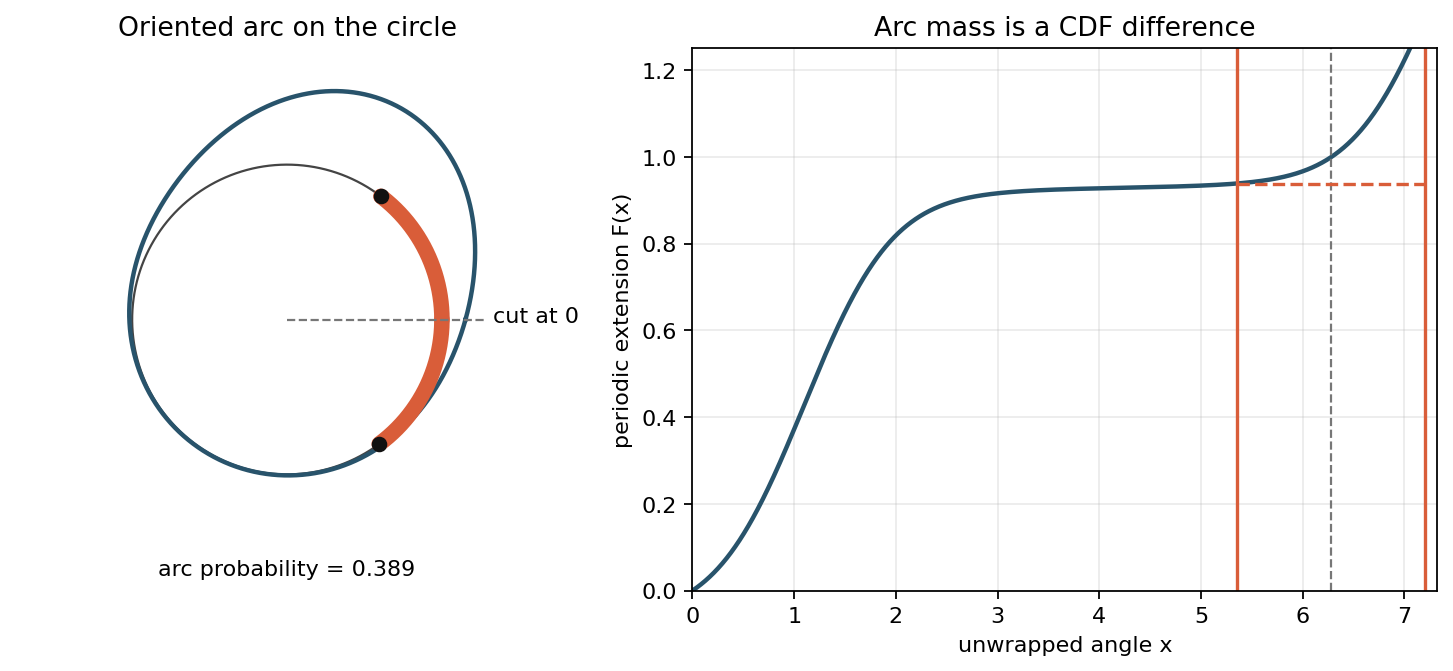

{'density_integral': 1.0,
 'arc_probability_cdf_difference': 0.3892230615779658,
 'arc_probability_split_integral': 0.3886075199061857,
 'arc_probability_residual': 0.0006155416717801288}

In [3]:
theta_cdf = np.linspace(0, TAU, 2401)
arc_mu = 1.10
arc_kappa = 2.35
arc_density = von_mises_density(theta_cdf, arc_mu, arc_kappa)
arc_cdf = cdf_from_density(theta_cdf, arc_density)
arc_start = 5.35
arc_end = 0.92
arc_end_unwrapped = arc_end + TAU
arc_prob = arc_probability(arc_start, arc_end, theta_cdf, arc_cdf)

split_mask_1 = theta_cdf >= arc_start
split_mask_2 = theta_cdf <= arc_end
split_integral = grid_integral(theta_cdf[split_mask_1], arc_density[split_mask_1]) + grid_integral(
    theta_cdf[split_mask_2], arc_density[split_mask_2]
)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"width_ratios": [1, 1.35]})

unit_x = np.cos(theta_cdf)
unit_y = np.sin(theta_cdf)
radial_density = 1.0 + 0.55 * arc_density / arc_density.max()
ax0.plot(unit_x, unit_y, color="#444444", lw=1.0)
ax0.plot(radial_density * unit_x, radial_density * unit_y, color="#28536B", lw=2.0, label="density radius")
for lo, hi in [(arc_start, TAU), (0.0, arc_end)]:
    segment = np.linspace(lo, hi, 220)
    ax0.plot(np.cos(segment), np.sin(segment), color="#D95D39", lw=7, solid_capstyle="round")
ax0.scatter([np.cos(arc_start), np.cos(arc_end)], [np.sin(arc_start), np.sin(arc_end)], color="#111111", zorder=3)
ax0.plot([0, 1.28], [0, 0], color="#777777", lw=1, ls="--")
ax0.text(1.33, 0.02, "cut at 0", ha="left", va="center")
ax0.text(0.0, -1.55, f"arc probability = {arc_prob:.3f}", ha="center", va="top")
ax0.set_aspect("equal")
ax0.set_xlim(-1.75, 1.75)
ax0.set_ylim(-1.75, 1.75)
ax0.axis("off")
ax0.set_title("Oriented arc on the circle")

x_ext = np.linspace(0, TAU + arc_end + 0.15, 2800)
y_ext = periodic_cdf(x_ext, theta_cdf, arc_cdf)
ax1.plot(x_ext, y_ext, color="#28536B", lw=2.0)
ax1.axvline(TAU, color="#777777", lw=1, ls="--")
ax1.axvline(arc_start, color="#D95D39", lw=1.5)
ax1.axvline(arc_end_unwrapped, color="#D95D39", lw=1.5)
fa = periodic_cdf(arc_start, theta_cdf, arc_cdf)
fb = periodic_cdf(arc_end_unwrapped, theta_cdf, arc_cdf)
ax1.hlines([fa, fb], arc_start, arc_end_unwrapped, color="#D95D39", lw=1.5, linestyles=["--", "-"])
ax1.annotate("same endpoint, next turn", xy=(arc_end_unwrapped, fb), xytext=(arc_end_unwrapped - 1.8, fb + 0.13), arrowprops={"arrowstyle": "->", "lw": 1})
ax1.set_xlim(0, TAU + arc_end + 0.12)
ax1.set_ylim(0, 1.25)
ax1.set_xlabel("unwrapped angle x")
ax1.set_ylabel("periodic extension F(x)")
ax1.set_title("Arc mass is a CDF difference")
ax1.grid(True, alpha=0.25)

arc_png = save_matplotlib(fig, TOPIC, "figures", "arc-probability-cdf.png")
plt.close(fig)
display_artifact(arc_png, width=980)

arc_diagnostics = {
    "density_integral": grid_integral(theta_cdf, arc_density),
    "arc_probability_cdf_difference": arc_prob,
    "arc_probability_split_integral": float(split_integral),
    "arc_probability_residual": float(abs(arc_prob - split_integral)),
}
arc_diagnostics


## Trigonometric Moments, Characteristic Functions, and Fourier Reconstruction

For line data the characteristic function accepts every real frequency. On the circle, the angle `theta` and `theta + 2*pi` are the same point, so the allowed frequencies are integers. The sequence `phi_p = E[exp(i p theta)]` stores the trigonometric moments: `Re(phi_p)` is the `p`th cosine moment and `Im(phi_p)` is the `p`th sine moment.

The next artifact treats a circular density as a signal. Low harmonics recover location and broad asymmetry; higher harmonics recover sharper shoulders or secondary features. This is the computational version of Fourier reconstruction from the chapter.


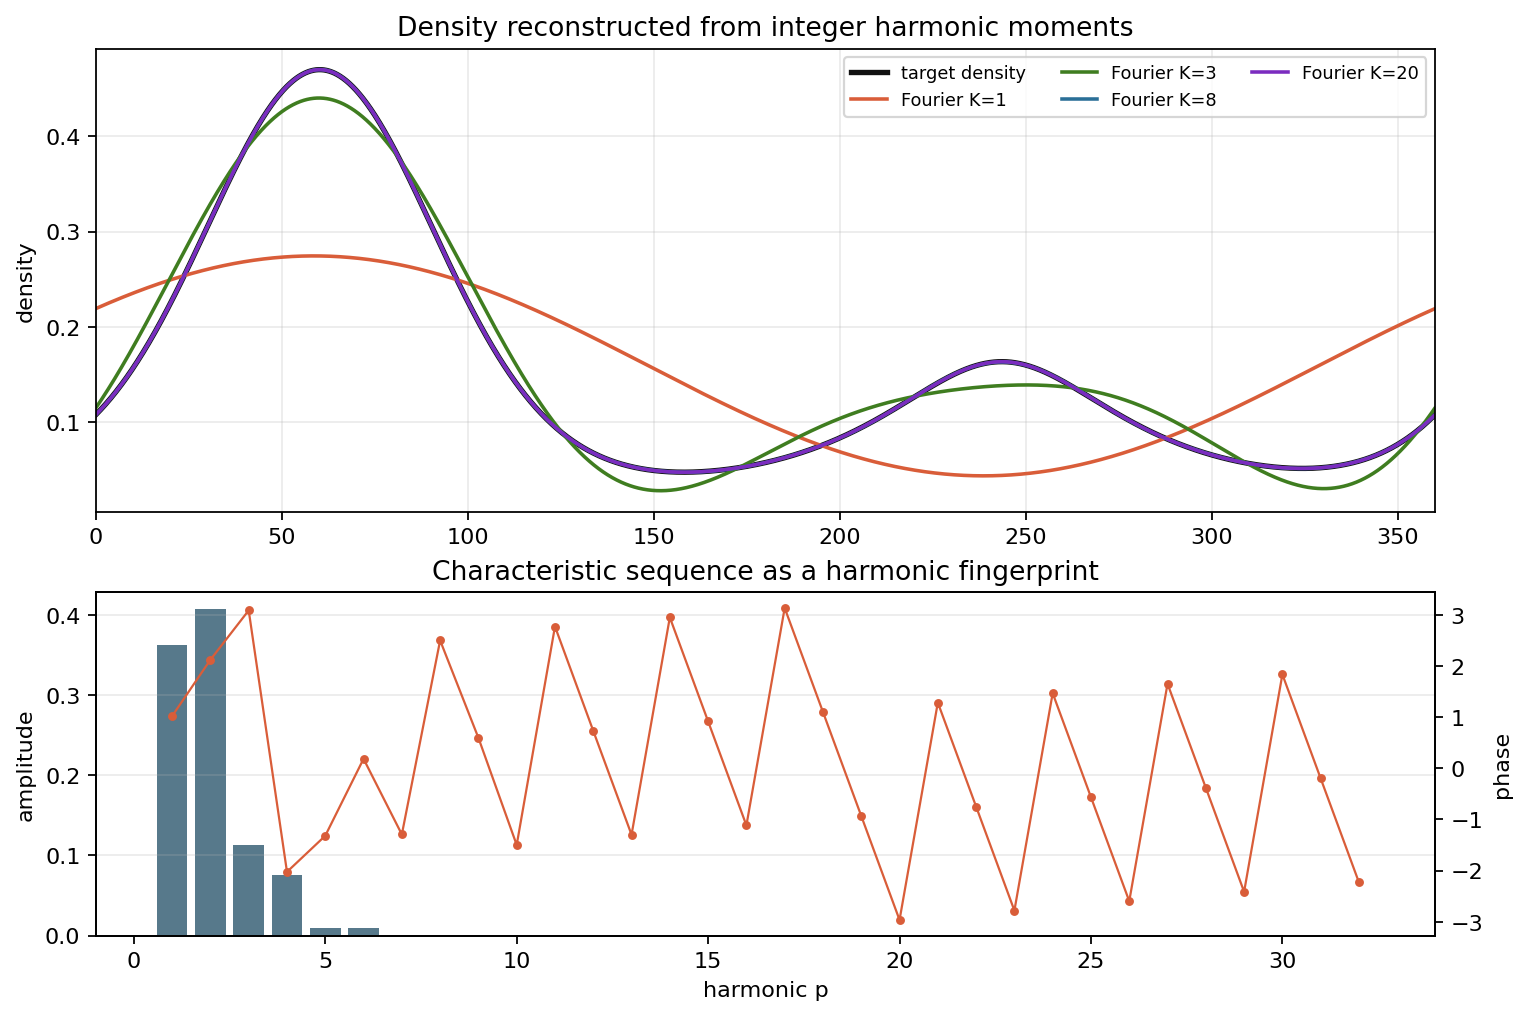

{'mixture_integral': 1.0,
 'max_trig_moment_identity_error_first_12': 8.543513119185775e-17,
 'reconstruction_l1_error_K20': 9.890925402637793e-08,
 'uniform_nonzero_characteristic_max_first_12': 6.834017936133213e-17}

In [4]:
theta_fourier = np.linspace(0, TAU, 4096, endpoint=False)
theta_fourier_closed = np.r_[theta_fourier, TAU]
mixture_density = (
    0.64 * von_mises_density(theta_fourier, mu=1.05, kappa=3.4)
    + 0.36 * wrapped_cauchy_density(theta_fourier, mu=4.25, rho=0.48)
)
mixture_density_closed = np.r_[mixture_density, mixture_density[0]]
coefficients = fourier_coefficients(theta_fourier_closed, mixture_density_closed, order=32)
recon_orders = [1, 3, 8, 20]
reconstructions = {order: fourier_reconstruction(theta_fourier, coefficients, order) for order in recon_orders}

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10.8, 7.2), gridspec_kw={"height_ratios": [1.35, 1]})
angle_deg = np.degrees(theta_fourier)
ax0.plot(angle_deg, mixture_density, color="#111111", lw=2.4, label="target density")
colors = {1: "#D95D39", 3: "#3F7D20", 8: "#2A6F97", 20: "#7B2CBF"}
for order in recon_orders:
    ax0.plot(angle_deg, reconstructions[order], lw=1.6, color=colors[order], label=f"Fourier K={order}")
ax0.set_xlim(0, 360)
ax0.set_ylabel("density")
ax0.set_title("Density reconstructed from integer harmonic moments")
ax0.legend(ncol=3, fontsize=8)
ax0.grid(True, alpha=0.25)

orders = np.arange(1, len(coefficients) + 1)
amplitudes = np.abs(coefficients)
phases = np.angle(coefficients)
ax1.bar(orders, amplitudes, color="#28536B", alpha=0.78, label="amplitude |phi_p|")
ax1.set_xlabel("harmonic p")
ax1.set_ylabel("amplitude")
ax1b = ax1.twinx()
ax1b.plot(orders, phases, color="#D95D39", marker="o", ms=3, lw=1, label="phase arg(phi_p)")
ax1b.set_ylabel("phase")
ax1.set_title("Characteristic sequence as a harmonic fingerprint")
ax1.grid(True, axis="y", alpha=0.25)

fourier_png = save_matplotlib(fig, TOPIC, "figures", "fourier-reconstruction.png")
plt.close(fig)
display_artifact(fourier_png, width=980)

alpha_beta_errors = []
for p, phi in enumerate(coefficients[:12], start=1):
    alpha = np.trapezoid(np.cos(p * theta_fourier_closed) * mixture_density_closed, theta_fourier_closed)
    beta = np.trapezoid(np.sin(p * theta_fourier_closed) * mixture_density_closed, theta_fourier_closed)
    alpha_beta_errors.append(abs(phi.real - alpha) + abs(phi.imag - beta))

fourier_diagnostics = {
    "mixture_integral": grid_integral(theta_fourier_closed, mixture_density_closed),
    "max_trig_moment_identity_error_first_12": float(max(alpha_beta_errors)),
    "reconstruction_l1_error_K20": float(np.mean(np.abs(reconstructions[20] - mixture_density)) * TAU),
    "uniform_nonzero_characteristic_max_first_12": float(
        max(abs(circular_moment(theta_fourier_closed, uniform_density(theta_fourier_closed), p)) for p in range(1, 13))
    ),
}
fourier_diagnostics


## Model Families as Generators

The chapter's named families are not just formulas; each is a way to generate a shape on the circle.

Uniform density assigns mass proportional to arc length. A small cardioid perturbation adds only a first harmonic and is useful near uniformity. The von Mises family is the circular analogue most directly tied to likelihood theory; matching the first resultant length uses the Bessel ratio `I_1(kappa)/I_0(kappa)`. Wrapped models come from reducing a line distribution modulo one turn. Projected models come from drawing a planar vector and keeping only its direction.

The gallery below compares several densities with a shared mean direction and comparable first resultant length where that comparison is meaningful. The projected panel uses an angular central Gaussian density, a zero-mean projected normal that is naturally axial: the first harmonic is near zero while the second harmonic is informative.


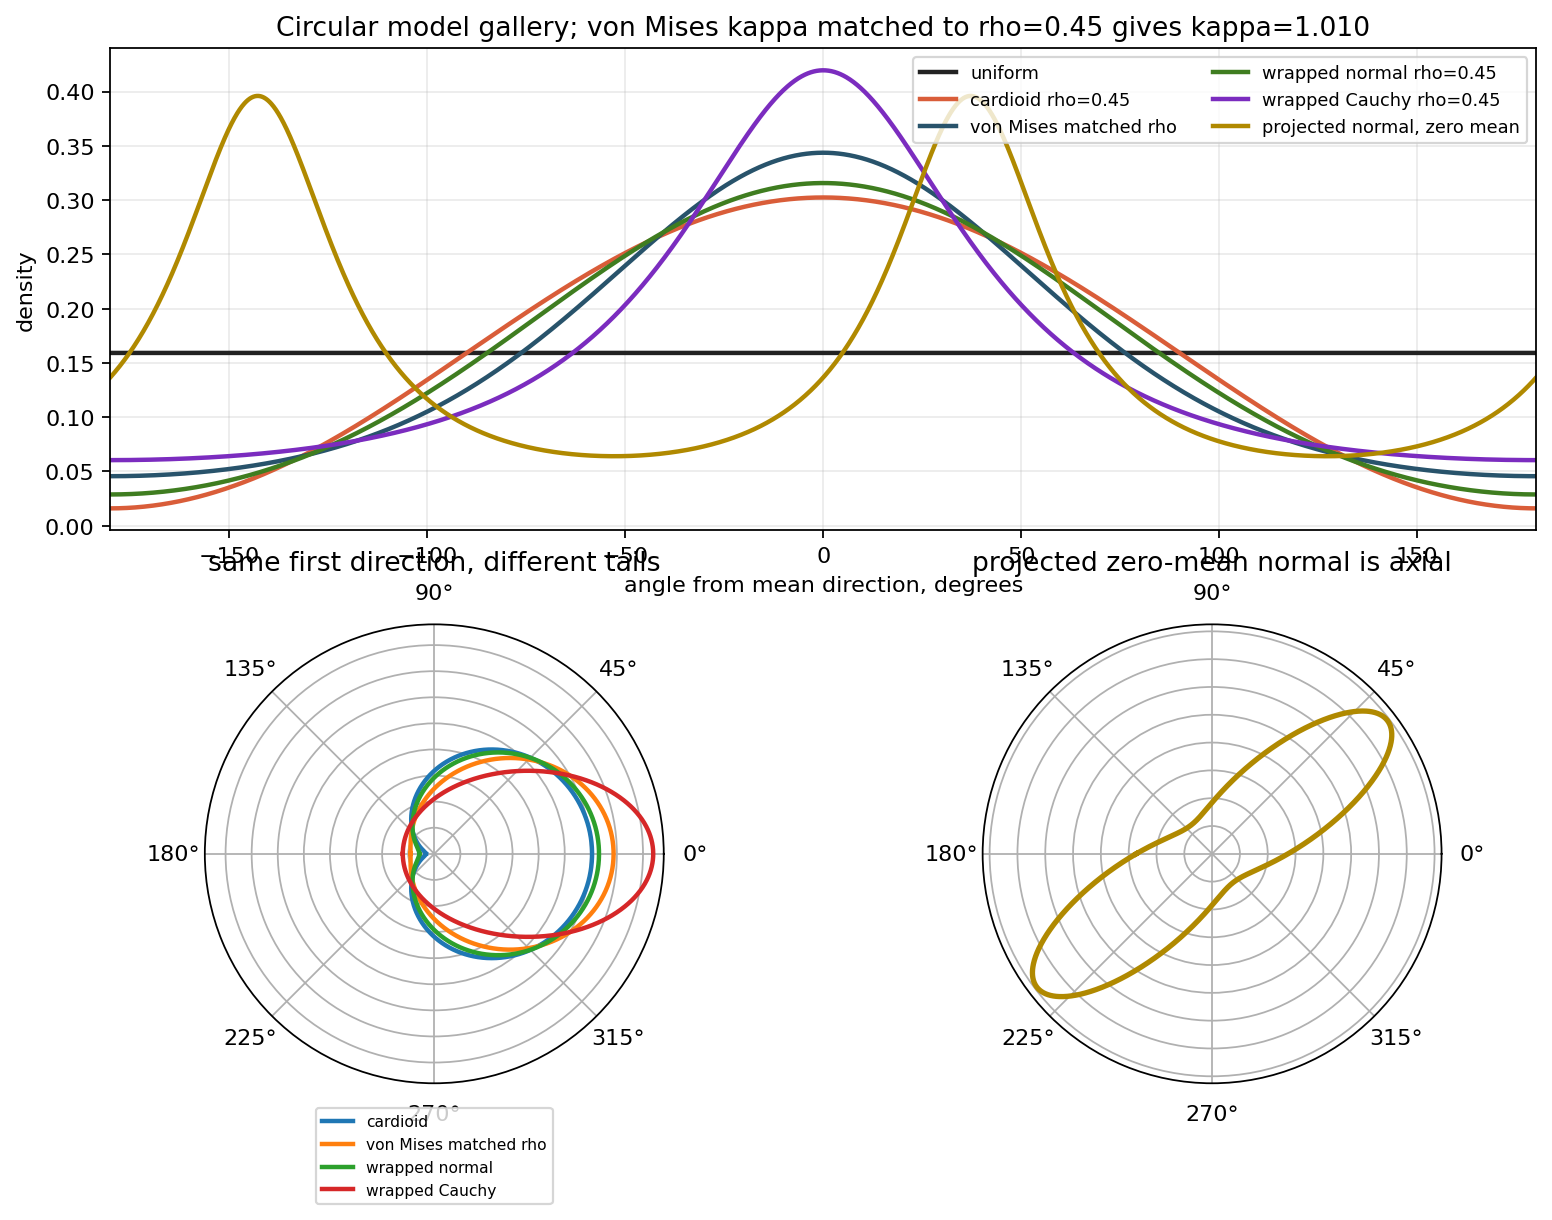

{'density_integrals': {'uniform': 0.9999999999999999,
  'cardioid rho=0.45': 1.0,
  'von Mises matched rho': 1.0000000000000002,
  'wrapped normal rho=0.45': 1.0,
  'wrapped Cauchy rho=0.45': 0.9999999999999998,
  'projected normal, zero mean': 0.9999999999999998},
 'moment_fingerprints': {'uniform': {'phi_1_abs': 6.206335383118183e-17,
   'phi_2_abs': 3.925231146709438e-17},
  'cardioid rho=0.45': {'phi_1_abs': 0.45, 'phi_2_abs': 0.0},
  'von Mises matched rho': {'phi_1_abs': 0.45000000000000007,
   'phi_2_abs': 0.10910578343903121},
  'wrapped normal rho=0.45': {'phi_1_abs': 0.45000000000000007,
   'phi_2_abs': 0.04100625000000002},
  'wrapped Cauchy rho=0.45': {'phi_1_abs': 0.44999999999999984,
   'phi_2_abs': 0.2024999999999999},
  'projected normal, zero mean': {'phi_1_abs': 5.551115123125783e-17,
   'phi_2_abs': 0.4266164787072931}},
 'kappa_matching_rho': 1.0102209479753739,
 'A_kappa_minus_rho': 5.551115123125783e-17,
 'cardioid_min_density': 0.01591549430918953}

In [5]:
theta_model = np.linspace(-np.pi, np.pi, 2401)
rho_shared = 0.45
mu_shared = 0.0
kappa_shared = kappa_from_resultant(rho_shared)

rot = np.array([[np.cos(0.65), -np.sin(0.65)], [np.sin(0.65), np.cos(0.65)]])
sigma_acg = rot @ np.diag([2.6, 0.42]) @ rot.T
families = {
    "uniform": uniform_density(theta_model),
    "cardioid rho=0.45": cardioid_density(theta_model, mu_shared, rho_shared),
    "von Mises matched rho": von_mises_density(theta_model, mu_shared, kappa_shared),
    "wrapped normal rho=0.45": wrapped_normal_density(theta_model, mu_shared, rho_shared),
    "wrapped Cauchy rho=0.45": wrapped_cauchy_density(theta_model, mu_shared, rho_shared),
    "projected normal, zero mean": angular_central_gaussian_density(theta_model, sigma_acg),
}

fig = plt.figure(figsize=(11.5, 8.4))
grid = fig.add_gridspec(2, 2, height_ratios=[1.05, 1.0])
ax0 = fig.add_subplot(grid[0, :])
ax1 = fig.add_subplot(grid[1, 0], projection="polar")
ax2 = fig.add_subplot(grid[1, 1], projection="polar")

palette = ["#222222", "#D95D39", "#28536B", "#3F7D20", "#7B2CBF", "#B08900"]
for (name, values), color in zip(families.items(), palette):
    ax0.plot(np.degrees(theta_model), values, lw=2, color=color, label=name)
ax0.set_xlim(-180, 180)
ax0.set_xlabel("angle from mean direction, degrees")
ax0.set_ylabel("density")
ax0.set_title(f"Circular model gallery; von Mises kappa matched to rho={rho_shared:.2f} gives kappa={kappa_shared:.3f}")
ax0.grid(True, alpha=0.25)
ax0.legend(ncol=2, fontsize=8)

for name in ["cardioid rho=0.45", "von Mises matched rho", "wrapped normal rho=0.45", "wrapped Cauchy rho=0.45"]:
    values = families[name]
    ax1.plot(theta_model, values, lw=2, label=name.replace(" rho=0.45", ""))
ax1.set_title("same first direction, different tails")
ax1.set_yticklabels([])
ax1.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), fontsize=7)

acg_values = families["projected normal, zero mean"]
ax2.plot(theta_model, acg_values, color="#B08900", lw=2.4)
ax2.plot(theta_model + np.pi, acg_values, color="#B08900", lw=1, alpha=0.35)
ax2.set_title("projected zero-mean normal is axial")
ax2.set_yticklabels([])

model_png = save_matplotlib(fig, TOPIC, "figures", "model-family-gallery.png")
plt.close(fig)
display_artifact(model_png, width=980)

model_integrals = {name: grid_integral(theta_model, values) for name, values in families.items()}
model_moments = {
    name: {
        "phi_1_abs": float(abs(circular_moment(theta_model, values, 1))),
        "phi_2_abs": float(abs(circular_moment(theta_model, values, 2))),
    }
    for name, values in families.items()
}
model_diagnostics = {
    "density_integrals": model_integrals,
    "moment_fingerprints": model_moments,
    "kappa_matching_rho": float(kappa_shared),
    "A_kappa_minus_rho": float(A_of_kappa(kappa_shared) - rho_shared),
    "cardioid_min_density": float(np.min(families["cardioid rho=0.45"])),
}
model_diagnostics


## Wrapping and Projection Compared

Wrapping and projection can both produce circular data, but they do not mean the same thing. Wrapping starts with a scalar on the line and folds it modulo one turn. Projection starts with a planar vector and discards its length. The next artifact makes the difference visible by comparing a wrapped normal curve with a simulated projected normal construction.


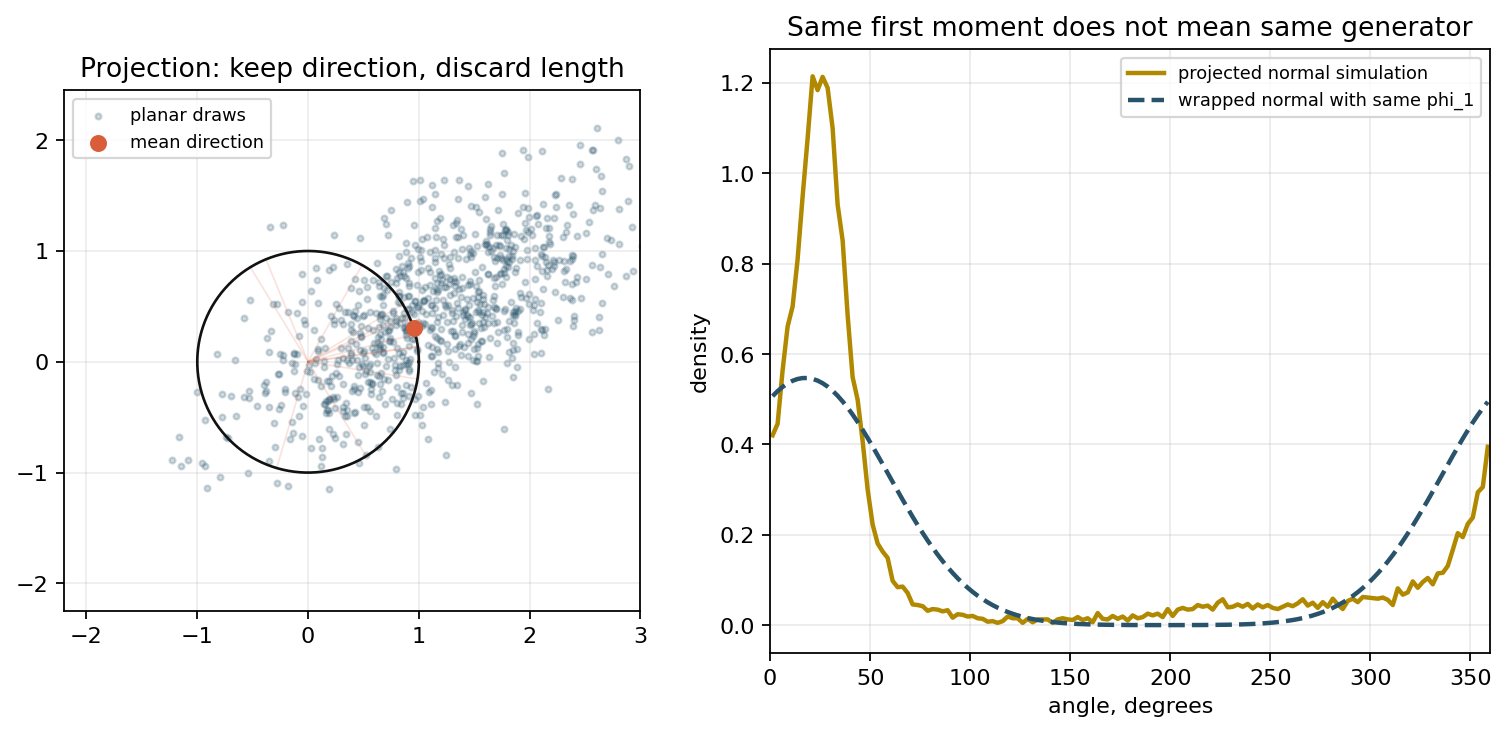

{'projected_resultant_length': 0.766588579919815,
 'projected_mean_direction': 0.30690352150361316,
 'histogram_integral': 1.0,
 'wrapped_match_integral': 1.0,
 'mean_abs_density_gap': 0.10271092842417567}

In [6]:
projection_mean = np.array([1.15, 0.45])
projection_cov = np.array([[0.70, 0.34], [0.34, 0.38]])
xy = rng.multivariate_normal(projection_mean, projection_cov, size=18_000)
angles_projected = wrap_angle(np.arctan2(xy[:, 1], xy[:, 0]))
projected_resultant = np.mean(np.exp(1j * angles_projected))
projected_mu = float(np.angle(projected_resultant) % TAU)
projected_rho = float(abs(projected_resultant))

hist_counts, hist_edges = np.histogram(angles_projected, bins=144, range=(0, TAU), density=True)
hist_centers = 0.5 * (hist_edges[:-1] + hist_edges[1:])
wrapped_match = wrapped_normal_density(hist_centers, projected_mu, projected_rho)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 4.9), gridspec_kw={"width_ratios": [1, 1.25]})
subset = xy[:850]
ax0.scatter(subset[:, 0], subset[:, 1], s=7, alpha=0.22, color="#28536B", label="planar draws")
unit = subset / np.linalg.norm(subset, axis=1, keepdims=True)
for j in range(0, len(unit), 75):
    ax0.plot([0, unit[j, 0]], [0, unit[j, 1]], color="#D95D39", alpha=0.16, lw=0.8)
circle = np.linspace(0, TAU, 500)
ax0.plot(np.cos(circle), np.sin(circle), color="#111111", lw=1.2)
ax0.scatter([np.cos(projected_mu)], [np.sin(projected_mu)], color="#D95D39", s=44, zorder=4, label="mean direction")
ax0.set_aspect("equal")
ax0.set_xlim(-2.2, 3.0)
ax0.set_ylim(-2.25, 2.45)
ax0.set_title("Projection: keep direction, discard length")
ax0.legend(fontsize=8)
ax0.grid(True, alpha=0.22)

ax1.plot(np.degrees(hist_centers), hist_counts, color="#B08900", lw=2.0, label="projected normal simulation")
ax1.plot(np.degrees(hist_centers), wrapped_match, color="#28536B", lw=2.0, ls="--", label="wrapped normal with same phi_1")
ax1.set_xlim(0, 360)
ax1.set_xlabel("angle, degrees")
ax1.set_ylabel("density")
ax1.set_title("Same first moment does not mean same generator")
ax1.grid(True, alpha=0.25)
ax1.legend(fontsize=8)

projected_png = save_matplotlib(fig, TOPIC, "figures", "wrapping-vs-projection.png")
plt.close(fig)
display_artifact(projected_png, width=980)

projection_diagnostics = {
    "projected_resultant_length": projected_rho,
    "projected_mean_direction": projected_mu,
    "histogram_integral": float(np.sum(hist_counts * np.diff(hist_edges))),
    "wrapped_match_integral": float(np.sum(wrapped_match * np.diff(hist_edges))),
    "mean_abs_density_gap": float(np.mean(np.abs(hist_counts - wrapped_match))),
}
projection_diagnostics


## Applied Lab: Model Fingerprints and Convolution Checks

Use this lab as a template for comparing circular models without flattening the circle. The lab records the first few characteristic-function amplitudes for each family, builds a Plotly explorer, and checks a convolution identity in the wrapped-normal case. The point is not that every distribution is recognized from two moments; it is that the moments give a coordinate-stable fingerprint that can be compared across models.


In [7]:
fingerprint_rows = []
for name, values in families.items():
    row = {"model": name, "integral": grid_integral(theta_model, values)}
    for p in range(1, 5):
        phi = circular_moment(theta_model, values, p)
        row[f"abs_phi_{p}"] = float(abs(phi))
        row[f"arg_phi_{p}"] = float(np.angle(phi))
    fingerprint_rows.append(row)

fingerprints_path = save_json({"rows": fingerprint_rows}, TOPIC, "checks", "model-fingerprints.json")
display_artifact(fingerprints_path)
fingerprint_rows


[{'model': 'uniform',
  'integral': 0.9999999999999999,
  'abs_phi_1': 6.206335383118183e-17,
  'arg_phi_1': -1.1071487177940904,
  'abs_phi_2': 3.925231146709438e-17,
  'arg_phi_2': 2.356194490192345,
  'abs_phi_3': 3.469446951953614e-17,
  'arg_phi_3': 0.0,
  'abs_phi_4': 2.7755575615628914e-17,
  'arg_phi_4': 3.141592653589793},
 {'model': 'cardioid rho=0.45',
  'integral': 1.0,
  'abs_phi_1': 0.45,
  'arg_phi_1': 0.0,
  'abs_phi_2': 0.0,
  'arg_phi_2': 0.0,
  'abs_phi_3': 4.443059973708341e-17,
  'arg_phi_3': 0.6747409422235526,
  'abs_phi_4': 2.6479404645468863e-17,
  'arg_phi_4': -2.5899376710612465},
 {'model': 'von Mises matched rho',
  'integral': 1.0000000000000002,
  'abs_phi_1': 0.45000000000000007,
  'arg_phi_1': 0.0,
  'abs_phi_2': 0.10910578343903121,
  'arg_phi_2': 0.0,
  'abs_phi_3': 0.01799239351472684,
  'arg_phi_3': 0.0,
  'abs_phi_4': 0.00224365460996993,
  'arg_phi_4': 1.8556048350062827e-14},
 {'model': 'wrapped normal rho=0.45',
  'integral': 1.0,
  'abs_phi_1':

In [8]:
fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.12,
    subplot_titles=("Model densities on one circular coordinate", "Fourier reconstruction of the mixture density"),
)
angle_deg_model = np.degrees(theta_model)
for name, values in families.items():
    fig.add_trace(go.Scatter(x=angle_deg_model, y=values, mode="lines", name=name), row=1, col=1)

fig.add_trace(go.Scatter(x=angle_deg, y=mixture_density, mode="lines", name="target density", line={"color": "black", "width": 3}), row=2, col=1)
for order in [1, 3, 8, 20]:
    fig.add_trace(
        go.Scatter(x=angle_deg, y=reconstructions[order], mode="lines", name=f"Fourier K={order}"),
        row=2,
        col=1,
    )
fig.update_xaxes(title_text="angle, degrees", row=2, col=1)
fig.update_yaxes(title_text="density", row=1, col=1)
fig.update_yaxes(title_text="density", row=2, col=1)
fig.update_layout(
    height=760,
    width=980,
    template="plotly_white",
    legend={"orientation": "h", "yanchor": "bottom", "y": -0.24, "xanchor": "left", "x": 0},
    margin={"l": 55, "r": 30, "t": 80, "b": 140},
)
interactive_html = save_plotly_html(fig, TOPIC, "interactive", "model-fourier-explorer.html", include_plotlyjs=True)
display_artifact(interactive_html, width="100%", height=820)


In [9]:
conv_theta = np.linspace(0, TAU, 4096, endpoint=False)
dtheta = TAU / len(conv_theta)
mu1, rho1 = 0.70, 0.62
mu2, rho2 = 1.35, 0.58
wn1 = wrapped_normal_density(conv_theta, mu1, rho1)
wn2 = wrapped_normal_density(conv_theta, mu2, rho2)
conv_fft = dtheta * np.fft.ifft(np.fft.fft(wn1) * np.fft.fft(wn2)).real
conv_expected = wrapped_normal_density(conv_theta, wrap_angle(mu1 + mu2), rho1 * rho2)
conv_phi_errors = []
conv_closed = np.r_[conv_fft, conv_fft[0]]
expected_closed = np.r_[conv_expected, conv_expected[0]]
conv_theta_closed = np.r_[conv_theta, TAU]
for p in range(1, 9):
    empirical_phi = circular_moment(conv_theta_closed, conv_closed, p)
    expected_phi = (rho1 ** (p * p) * np.exp(1j * p * mu1)) * (rho2 ** (p * p) * np.exp(1j * p * mu2))
    conv_phi_errors.append(abs(empirical_phi - expected_phi))

convolution_diagnostics = {
    "wrapped_normal_convolution_integral": float(np.sum(conv_fft) * dtheta),
    "wrapped_normal_convolution_max_abs_error": float(np.max(np.abs(conv_fft - conv_expected))),
    "wrapped_normal_phi_product_max_error_first_8": float(max(conv_phi_errors)),
}
convolution_diagnostics


{'wrapped_normal_convolution_integral': 0.9999999999999997,
 'wrapped_normal_convolution_max_abs_error': 1.8041124150158794e-16,
 'wrapped_normal_phi_product_max_error_first_8': 1.6653345369377348e-16}

## Sanity Checks

The checks below are deliberately mathematical, not just file-existence checks. They assert density normalization, equivalence of arc-probability computations, moment identities, Bessel-ratio matching for the von Mises gallery, projected/wrapped artifact integrity, and the convolution rule for wrapped normals.


In [10]:
all_density_integrals = {
    "arc_von_mises": arc_diagnostics["density_integral"],
    "mixture_density": fourier_diagnostics["mixture_integral"],
    **{f"model_{key}": value for key, value in model_integrals.items()},
}
normalization_errors = {key: abs(value - 1.0) for key, value in all_density_integrals.items()}

numeric_checks = {
    "source_span": source_span,
    "arc": arc_diagnostics,
    "fourier": fourier_diagnostics,
    "models": model_diagnostics,
    "projection": projection_diagnostics,
    "convolution": convolution_diagnostics,
    "normalization_errors": normalization_errors,
    "normalization_ok": all(error < 2e-3 for error in normalization_errors.values()),
    "arc_probability_ok": arc_diagnostics["arc_probability_residual"] < 2e-3,
    "trig_moment_identity_ok": fourier_diagnostics["max_trig_moment_identity_error_first_12"] < 1e-12,
    "uniform_characteristic_ok": fourier_diagnostics["uniform_nonzero_characteristic_max_first_12"] < 1e-12,
    "von_mises_bessel_ratio_ok": abs(model_diagnostics["A_kappa_minus_rho"]) < 1e-10,
    "cardioid_nonnegative_ok": model_diagnostics["cardioid_min_density"] >= -1e-12,
    "wrapped_normal_convolution_ok": convolution_diagnostics["wrapped_normal_convolution_max_abs_error"] < 5e-4,
    "wrapped_normal_characteristic_product_ok": convolution_diagnostics["wrapped_normal_phi_product_max_error_first_8"] < 5e-4,
}

boolean_checks = {key: value for key, value in numeric_checks.items() if key.endswith("_ok")}
assert boolean_checks and all(boolean_checks.values()), boolean_checks

checks_path = save_json(numeric_checks, TOPIC, "checks", "numeric-checks.json")
display_artifact(checks_path)
boolean_checks


{'normalization_ok': True,
 'arc_probability_ok': True,
 'trig_moment_identity_ok': True,
 'uniform_characteristic_ok': True,
 'von_mises_bessel_ratio_ok': True,
 'cardioid_nonnegative_ok': True,
 'wrapped_normal_convolution_ok': True,
 'wrapped_normal_characteristic_product_ok': True}

In [11]:
artifact_paths = [
    arc_png,
    fourier_png,
    model_png,
    projected_png,
    interactive_html,
    fingerprints_path,
    checks_path,
]
artifact_status = assert_artifacts(artifact_paths, min_bytes=200)
final_sanity = {
    "artifact_status": artifact_status,
    "numeric_check_bools": boolean_checks,
    "artifact_count": len(artifact_paths),
    "standalone_contract": "chapter-specific prose, direct code, generated artifacts, and executable checks",
}
final_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert final_path.exists() and final_path.stat().st_size > 200
final_sanity


{'artifact_status': [{'path': 'artifacts/chapter-03/figures/arc-probability-cdf.png',
   'exists': True,
   'bytes': 78891},
  {'path': 'artifacts/chapter-03/figures/fourier-reconstruction.png',
   'exists': True,
   'bytes': 178046},
  {'path': 'artifacts/chapter-03/figures/model-family-gallery.png',
   'exists': True,
   'bytes': 341504},
  {'path': 'artifacts/chapter-03/figures/wrapping-vs-projection.png',
   'exists': True,
   'bytes': 162136},
  {'path': 'artifacts/chapter-03/interactive/model-fourier-explorer.html',
   'exists': True,
   'bytes': 5758520},
  {'path': 'artifacts/chapter-03/checks/model-fingerprints.json',
   'exists': True,
   'bytes': 2270},
  {'path': 'artifacts/chapter-03/checks/numeric-checks.json',
   'exists': True,
   'bytes': 3007}],
 'numeric_check_bools': {'normalization_ok': True,
  'arc_probability_ok': True,
  'trig_moment_identity_ok': True,
  'uniform_characteristic_ok': True,
  'von_mises_bessel_ratio_ok': True,
  'cardioid_nonnegative_ok': True,
 

## Takeaways

Arc probabilities are the primitive probability statements on the circle; the ordinary-looking distribution function is a coordinate device that must be extended by `F(x + 2*pi) = F(x) + 1`.

The circular characteristic function is a sequence, not a real-frequency function. Its entries are exactly the trigonometric moments, and Fourier partial sums turn those moments back into inspectable density approximations.

The named model families encode different generative stories. Von Mises is tied to Bessel normalization and likelihood theory; cardioid is a first-harmonic perturbation; wrapped models inherit modulo-addition behavior from line distributions; projected models come from planar vectors and can be axial or asymmetric.

The final checks are part of the lesson: a circular density should integrate to one around a full turn, uniform nonzero harmonics should vanish, matched von Mises concentration should satisfy the Bessel-ratio equation, and convolution should multiply characteristic functions.
